In [ ]:
# TODO Stability anal -> see Klaus + my Claude; compute new J_crit
# TODO finish Inactivating task
# TODO finish tasks

# Build Model

In [1]:
import os
import sys
os.environ["OPENBLAS_NUM_THREADS"] = "1"   # ← the one that matters for your setup
os.environ["OMP_NUM_THREADS"]      = "1"   # good to set too
# must be set BEFORE importing numpy
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import matplotlib.lines as mlines
import scipy
from scipy.sparse import csr_matrix
import seaborn as sns
from itertools import product
from matplotlib.colors import LinearSegmentedColormap
from joblib import Parallel, delayed
from matplotlib.lines import Line2D
import matlab.engine
import h5py
from scipy.optimize import curve_fit, brentq

Define the function that transforms input current to changes in firing rate for excitatory neurons (Abbott and Chance, 2005). 
<br>
$$\phi_E = \frac{aI_{syn,E} - b}{1 - e^{-d(aI_{syn,E} - b)}} $$

Update the firing rates of the interneurons using a threshold linear input/output function
$$ \phi_I = \begin{cases}
  \frac{1}{g_I}(c_II_{syn,I} - c_0) + r_0 & \text{for } \phi_I\ge 0\\    
  0     & \text{otherwise }  
\end{cases} $$


In [2]:
def phi_E(I, a_E, b_E, d_E):
    a_expanded = np.tile(a_E, 2)[:, None]   # shape (60, 1)
    return (a_expanded * I - b_E) / (1 - np.exp(-d_E * (a_expanded * I - b_E)))

def phi_I(I, g_I, c_1, c_0, r0_I):
    return np.maximum((1 / g_I) * (c_1 * I - c_0) + r0_I, 0)

In [16]:
def aging_a_e(perc):
    # ── Data ─────────────────────────────────────────────────────────────
    full_df = pd.read_excel("data/EPHYS_Aver_byMonkey.xlsx")
    df = full_df.iloc[:, 14:22].copy()  # Only look at the FI and rheobase data
    rb = full_df[['Age Group', 'rheobase']].copy()

    age_order = ["Y", "MA", "Aged"]

    # Split into ages, averaging
    df["Age Group"] = pd.Categorical(full_df["Age Group"], categories=age_order, ordered=True)
    rb["Age Group"] = pd.Categorical(rb["Age Group"], categories=age_order, ordered=True)
    rb["rheobase"] = rb["rheobase"] / 1000

    group_mean = df.groupby("Age Group",observed=False).mean()
    group_sem = df.groupby("Age Group",observed=False).sem()
    rheo_mean = rb.groupby("Age Group",observed=False).mean()
    rheo_sem = rb.groupby("Age Group",observed=False).sem()

    # Take the Y monkey as baseline
    young_fi = group_mean.loc["Y"].values
    young_rheo = rheo_mean.loc["Y"].values.squeeze()

    # ── Model ────────────────────────────────────────────────────────────
    a_Y, b_Y, d_E = 135, 54, 0.308

    def phi_E(I, a_E, b_E):
        x = a_E * I - b_E
        return x / (1 - np.exp(-d_E * x))

    # 1 Hz rheobase definition
    def rheobase_1hz(a_E, b_E, I_min=0.0, I_max=2.0):
        def f(I):
            return phi_E(I, a_E, b_E) - 1.0
        try:
            return brentq(f, I_min, I_max)
        except ValueError:
            return np.nan

    # Define the Y monkey rheobase
    I_rheo_Y = rheobase_1hz(a_Y, b_Y)

    # Define the Y monkey curve
    xc = np.linspace(0, 1, 500)
    y_young = phi_E(xc, a_Y, b_Y)

    # ── Fit ──────────────────────────────────────────────────────────────
    results = {"Y": {"a": a_Y, "b": b_Y, "label": "Young"}}

    for g in ["MA", "Aged"]:
        # Compute percent change for MA and A with Y as baseline
        pct_fi = np.mean((group_mean.loc[g].values - young_fi) / young_fi * 100)
        pct_rheo = (rheo_mean.loc[g].values.squeeze() - young_rheo) / young_rheo * 100

        # Define the target values of the curves and rheobase with MA and A aging
        y_target = y_young * (1 + pct_fi * perc/ 100)
        target_rheo = I_rheo_Y * (1 + pct_rheo * perc / 100)

        # (starting guess)
        a0 = a_Y * (1 + pct_fi / 100)

        # for each a, solve b such that rheobase matches target
        def solve_b(a_E):
            def err(b):
                r = rheobase_1hz(a_E, b)
                return r - target_rheo
            try:
                return brentq(err, 0.1, 500)
            except ValueError:
                return b_Y
            
        def constrained_model(I, a_E):
            b_E = solve_b(a_E)
            return phi_E(I, a_E, b_E)

        try:
            popt, _ = curve_fit(
                constrained_model,
                xc,
                y_target,
                p0=[a0],
                bounds=([0], [500]),
                maxfev=10000
            )
            a_E = popt[0]
        except RuntimeError:
            a_E = a0

        b_E = solve_b(a_E)

        results[g] = {"a": a_E, "b": b_E}

        # print(f"{proper_age_labels[g]}: a_E = {a_E:.3f}, b_E = {b_E:.3f}")
    return results

class BuildModel:
    def __init__(self, J_max = 0.42, G = 0.48, age = "Y", aging_mechanism = None, perc=0.4): 
        if aging_mechanism == None:
            aging_mechanism = set()
        elif 'FI' not in aging_mechanism and 'spine' not in aging_mechanism and 'longrange' not in aging_mechanism:
            raise Exception("Aging factor naming error")
        
        ######## ANATOMICAL DATA #########
        subgraph_data = sio.loadmat('data/subgraphData30.mat')
        fln = subgraph_data['fln']  # FLN (fraction of labelled neurons)
        sln = subgraph_data['sln']  # SLN (supragranular layered neurons)

        self.area_list = np.array(['V1','V2','V4','DP','MT','8m','5','8l','2','TEO','F1','STPc','7A','46d','10','9/46v','9/46d','F5','TEpd','PBr','7m','LIP','F2','7B','ProM','STPi','F7','8b','STPr','24c'])
        frontal = np.array([5,7,10,13,14,15,16,17,22,24,26,27]);  # areas in frontal lobe

        self.occipital = np.array([0, 1, 2, 4])                # V1, V2, V4, MT
        self.parietal = np.array([3, 6, 8, 12, 20, 21, 23])   # DP, 5, 2, 7A, 7m, LIP, 7B
        self.temporal = np.array([9, 11, 18, 19, 25, 28])     # TEO, STPc, TEpd, PBr, STPi, STPr
        self.frontal = np.array([10, 13, 14, 17, 22, 24, 26, 29]) # F1, 46d, 10, F5, F2, ProM, 24c, F7
        self.prefrontal = np.array([5, 7, 15, 16, 27])    # 8m, 8l, 9/46v, 9/46d, 8b

        self.num_areas = fln.shape[0]
        self.hierarchy = np.squeeze(subgraph_data['hierVals'])
        # hierarchy is cortical hierarchy 

        # Make feedback connections target more inhibitory cells
        lambdai = np.ones((self.num_areas,self.num_areas)) - sln # for long-range connections

        # SPINE COUNT DATA (Elston, several papers):
        spinec = np.array([643, 1201, 2429, -10, 2077, 3200, 4689, 3200, -10, 4812, -10, 8337, 2572, 6600,  # 46d
            6488, 7800, 7800, -10, 6200, -10, 2294, 2316, -10, 6841, -10, 8337, -10, -10, 8337, 6825])  #24c
        # AGE FACTOR:
        # Level the age factors for a young monkey Y
        AF = np.ones((self.num_areas,)) 
        AF[[13,14,15,16,18,29]] = AF[[13,14,15,16,18,29]] * 1.15  # 5yo, 15% increase
        AF[[5,7,20]] = AF[[5,7,20]] * 1.30  # 10yo, 30% increase
        spinec = spinec * AF  # age correction
        hierVals2 = spinec / np.max(spinec)

        # Now the ones based on hierarchical positions:
        hierVals2[spinec < 0] = self.hierarchy[spinec < 0]

        self.hierarchy = hierVals2
        self.spinec = spinec

        # We cap the inhibitory long-range strength to FEF from frontal areas.
        maxi = 0.4
        idx = lambdai[frontal[0],frontal] > maxi
        lambdai[frontal[0],frontal[idx]] = maxi
        idx = lambdai[frontal[1],frontal] > maxi
        lambdai[frontal[1],frontal[idx]] = maxi

        ######## PARAMETERS ########

        # Set up simulation parameters
        self.dt = 0.5 * 1e-3  # timestep [s]
        self.dt_rate = 10e-3  # store firing rate every 10 ms
        self.num_pops = 3

        # Time constants
        self.tau_NMDA = 60 * 1e-3  # s
        self.tau_GABA = 5 * 1e-3  # s
        self.tau_AMPA = 2 * 1e-3  # s
        self.tau_r = 2 * 1e-3  # s

        # Kinetic parameters of NMDA and GABA
        self.gamma = 1.282  # unitless
        self.gamma_i = 2.  # unitless

        # f-I curve parameters - E populations
        self.a_E = 135*np.ones(30) # Hz/nA
        self.b_E = 54. # Hz
        self.d_E = 0.308  # s

        # f-I curve parameters - I populations
        self.g_I = 4.  # unitless
        self.c_1 = 615.  # Hz/nA
        self.c_0 = 177 # Hz
        self.r0_I = 5.5  # Hz

        if 'FI' in aging_mechanism:
            a_E_by_age = {
                        'Y': 135 * np.ones(30),
                        'MA': np.linspace(135.5, aging_a_e(perc)['MA']['a'], 30),
                        'A': np.linspace(136, aging_a_e(perc)['Aged']['a'], 30),
                        }
            b_E_by_age = {
                        'Y': self.b_E,
                        'MA': aging_a_e(perc)['MA']['b'],
                        'A': aging_a_e(perc)['Aged']['b'],
                        }
            try:
                self.a_E = a_E_by_age[age]  # Hz/nA
                self.b_E = b_E_by_age[age] # Hz

            except KeyError:
                raise ValueError(f"Unknown age: {age}")
            
        # Local connectivity matrix strengths
        # Strength of connections from E cells
        g_E_self_min = 0.21  # nA
        J_max = J_max  # nA
        g_E_cross = 0.0107  # nA

        # Strength of connections from I cells
        g_E_I = -0.31  # nA
        g_I_I = -0.12  # nA

        # Excitatory input constant ("John Murray's term")
        J_0 = 0.2112  # nA - Matches value in John Murray's thesis for g_E_self - g_E_cross

        # Global coupling strength
        G = G  # unitless

        ######## HIERARCHY ########        
        self.g_E_self = g_E_self_min + (J_max - g_E_self_min) * self.hierarchy 
        # Scale the E to I synapses to lie along the hierarachy (ensuring that the spontaneous activity fixed point is the same across areas)
        zeta = self.c_1 * self.tau_GABA * self.gamma_i / (self.g_I - g_I_I * self.tau_GABA * self.gamma_i * self.c_1)  # Eq. 14
        g_I_E = (J_0 - self.g_E_self - g_E_cross) / (2 * zeta * g_E_I)    # Eq. 17
        ####### LONG-RANGE CONNECTIONS ########

        # Long-range coupling strength
        mu_EE = G  
        Z = 2 * self.c_1 * self.tau_GABA * self.gamma_i * g_E_I / (self.c_1 * self.tau_GABA * self.gamma_i * g_I_I - self.g_I)    # constant to maintain EI balance; Eq. 21
        mu_IE = G / Z

        # Compress FLN (fraction of labelled neurons)
        if J_max > 0.4655:
            newindex = np.argsort(self.g_E_self)

            # Reorder into hierarchical space
            fln_sorted = fln[np.ix_(newindex, newindex)]

            # Remove feedback (keep lower triangle only)
            fln_sorted = np.tril(fln_sorted)

            # Map back to original ordering
            inv_index = np.argsort(newindex)
            fln = fln_sorted[np.ix_(inv_index, inv_index)]
            
        # elif cutFB == 2:
        #     fln=np.tril(fln)

        fln_squish = 1.2 * np.power(fln,0.3)    
        fln_rowtotal = np.sum(fln_squish,axis=1)        
        fln_squishnorm = fln_squish / np.maximum(fln_rowtotal[:, np.newaxis] , 0.1)

        # Make feedforward connections target more excitatory cells
        W_E = fln_squishnorm * sln
        W_I = fln_squishnorm * lambdai
                
        ####### CONNECTIVITY MATRIX ########

        # Compute effective connectivity matrix for excitatory connections
        LR_EE_gradient = self.g_E_self / np.max(self.g_E_self)
        W_E_eff = mu_EE * LR_EE_gradient[:, np.newaxis] * W_E 

        if 'spine' in aging_mechanism: # D is ordered by spine count  
            D_by_age = {
                'Y': np.ones_like(self.hierarchy),
                'MA': 0.825 - 0.009 * np.arange(30),
                'A': 0.874 - 0.017 * np.arange(30),
            }

            try:
                D = D_by_age[age]
            except KeyError:
                raise ValueError(f"Unknown age: {age}")

            D = D[np.argsort(self.hierarchy)] # Now D follows cortical hierarchy
            self.g_E_self += (self.g_E_self - g_E_self_min) * (D-1) 

        # Compute effective connectivity matrix for inhibitory connections
        LR_IE_gradient = g_I_E / np.max(g_I_E)
        W_I_eff = mu_IE * LR_IE_gradient[:, np.newaxis] * W_I 

        if 'longrange' in aging_mechanism:
            loss_by_age = {'Y': 0.0, 'MA': 0.10, 'A': 0.20}
            try:
                scale = 1.0 - loss_by_age[age]
            except KeyError:
                raise ValueError(f"Unknown age: {age}")

            def idx(*names):
                return np.where(np.isin(self.area_list, list(names)))[0]

            # Each bundle: (source_areas, target_areas) — applied bidirectionally
            bundles = [
                # SLF II: parietal <-> frontal/prefrontal
                (idx('7A','LIP','DP','7B'),
                idx('46d','9/46d','8l','8m','8b','F2','F7')),
                # Cingulum bundle
                (idx('10','9/46v','8m','24c'),
                idx('7m')),
                # SLF III
                (idx('7B','STPc','STPi'),
                idx('F5','8l','9/46v','ProM')),
                # Uncinate fasciculus
                (idx('10'),
                idx('STPr','PBr')),
                # Fronto-cingulate
                (idx('24c'),
                idx('F1','F2','F7','8m')),
            ]
            for src, tgt in bundles:
                # src -> tgt
                W_E_eff[np.ix_(tgt, src)] *= scale
                W_I_eff[np.ix_(tgt, src)] *= scale
                # tgt -> src (bidirectional)
                W_E_eff[np.ix_(src, tgt)] *= scale
                W_I_eff[np.ix_(src, tgt)] *= scale

            D_by_age = {
                'Y': np.ones_like(self.hierarchy),
                'MA': 0.825 - 0.009 * np.arange(30),
                'A': 0.874 - 0.017 * np.arange(30),
            }

            try:
                D = D_by_age[age]
            except KeyError:
                raise ValueError(f"Unknown age: {age}")

            D = D[np.argsort(self.hierarchy)]
            W_E_eff *= D[:, np.newaxis]
            W_I_eff *= D[:, np.newaxis]

        np.fill_diagonal(W_E_eff, self.g_E_self)  # include self population weights in effective connectivity matrix
        np.fill_diagonal(W_I_eff, g_I_E)

        # Construct joint connectivity matrix for all 3 populations (E1, E2, and I)
        self.W_eff = np.zeros((self.num_areas*self.num_pops,self.num_areas*self.num_pops))
        self.W_eff[:self.num_areas,:self.num_areas] = W_E_eff  # excitatory to excitatory connections E1 -> E1
        self.W_eff[self.num_areas:2*self.num_areas,self.num_areas:2*self.num_areas] = W_E_eff  # excitatory to excitatory connections E2 -> E2
        np.fill_diagonal(self.W_eff[:self.num_areas,self.num_areas:2*self.num_areas], g_E_cross)  # excitatory to excitatory connections E1 -> E2
        np.fill_diagonal(self.W_eff[self.num_areas:2*self.num_areas,:self.num_areas], g_E_cross)  # excitatory to excitatory connections E2 -> E1
        self.W_eff[2*self.num_areas:,:self.num_areas] = W_I_eff  # excitatory to inhibitory connections E1 -> I
        self.W_eff[2*self.num_areas:,self.num_areas:2*self.num_areas] = W_I_eff  # excitatory to inhibitory connections E2 -> I
        np.fill_diagonal(self.W_eff[:self.num_areas,2*self.num_areas:], g_E_I)  # inhibitory to excitatory connections I -> E1
        np.fill_diagonal(self.W_eff[self.num_areas:2*self.num_areas,2*self.num_areas:], g_E_I)  # inhibitory to excitatory connections I -> E2
        np.fill_diagonal(self.W_eff[2*self.num_areas:,2*self.num_areas:], g_I_I)  # inhibitory to inhibitory connections I -> I
        self.W_eff = csr_matrix(self.W_eff)
        pass

    def con_matrix(self, Mat = None):
        # Connectivity matrix for excitatory and inhibitory neurons
        if Mat is not None:
            self.W_eff = Mat
        plt.figure(figsize=(12, 8))
        W = self.W_eff.todense()
        N = W.shape[0]
        k = N // 3

        labels = ["E1", "E2", "I"]
        centers = [k/2, k + k/2, 2*k + k/2]

        def add_block_lines(ax):
            ax.axvline(k, linestyle=':', color='black', alpha=0.1)
            ax.axvline(2*k, linestyle=':', color='black', alpha=0.1)
            ax.axhline(k, linestyle=':', color='black', alpha=0.1)
            ax.axhline(2*k, linestyle=':', color='black', alpha=0.1)

        # --- First subplot ---
        ax1 = plt.subplot(2, 2, 1)
        im1 = ax1.imshow(W, cmap='RdBu', vmin=-np.max(W), vmax=np.max(W))
        plt.colorbar(im1, ax=ax1)
        ax1.set_title('Connectivity matrix W')

        ax1.set_xticks(centers)
        ax1.set_yticks(centers)
        ax1.set_xticklabels(labels)
        ax1.set_yticklabels(labels)
        ax1.xaxis.tick_top()
        ax1.xaxis.set_label_position('top')
        add_block_lines(ax1)

        # --- Second subplot ---
        ax2 = plt.subplot(2, 2, 2)
        W_eff_ = W.copy()

        np.fill_diagonal(W_eff_, 0)
        np.fill_diagonal(W_eff_[:2*self.num_areas, self.num_areas:], 0)
        np.fill_diagonal(W_eff_[self.num_areas:, :2*self.num_areas], 0)
        np.fill_diagonal(W_eff_[:self.num_areas, 2*self.num_areas:], 0)
        np.fill_diagonal(W_eff_[2*self.num_areas:, :self.num_areas], 0)

        im2 = ax2.imshow(W_eff_, cmap='RdBu', vmin=-np.max(W_eff_), vmax=np.max(W_eff_))
        plt.colorbar(im2, ax=ax2)
        ax2.set_title('Connectivity matrix W (inter-area only)')

        ax2.set_xticks(centers)
        ax2.set_yticks(centers)
        ax2.set_xticklabels(labels)
        ax2.set_yticklabels(labels)
        ax2.xaxis.tick_top()
        ax2.xaxis.set_label_position('top')
        add_block_lines(ax2)
        # plt.savefig('Fig/W.svg', dpi=150, bbox_inches='tight')
        plt.show()

    def runsim(self, stim=[4, 4.5, 0.3, 'V1'], distract=[3.5, 4, 0], inhi = [9, 9.5, 0.3, None], trial_length = 10, lesion = [False, None], trials = 1, save_fac = 1):
        # Stim/distract.inhi: [start (s), end (s), strenght (nA), area(s) ] of stimulus or distractor or inhibition  
        # Lesioned areas    [Bool perm [switch on and off], list lesioned area(s)]

        # You can run multiple trials (trials parameter) and varry the stim/dis/inhi strenght but none of the other parameters sadly

        # Trial parameters
        self.trial_length = trial_length  # trial length (s)
        self.num_iterations = int(self.trial_length/self.dt)
        # Lesioned areas    [Bool perm, lesioned area(s)]
        self.perm , self.lesioned_areas = lesion
        lesion_indexes = np.where(np.isin(self.area_list, self.lesioned_areas))[0]

        self.trials = trials  # number of trials computed at the same time with same parameters
        ####### EXT INPUTS AND NOISE ########

        # Background inputs
        I0_E = 0.3294  # nA
        I0_I = 0.26  # nA

        I0 = np.concatenate((I0_E * np.ones(2*self.num_areas), I0_I * np.ones(self.num_areas) ))
        I0 = np.repeat(I0[:, None], self.trials, axis=1)  # (90, trials)

        # Let's apply external stimulation to some area populations E1 & E2        
        # Stimulus and distractor
        self.stim_on, self.stim_off, self.stim_strength , self.stim_areas = stim
        self.distract_on, self.distract_off, self.distractor_strength = distract
        self.inhi_on, self.inhi_off, self.inhi_strength , self.inhi_areas = inhi   

        # Locate where (area index) the stimulus/distraction/inhibition must be applied
        stim_idx = np.where(np.isin(self.area_list, self.stim_areas))[0]
        dist_idx = np.where(np.isin(self.area_list, self.stim_areas))[0] + self.num_areas
        inhi_idx = np.where(np.isin(self.area_list, self.inhi_areas))[0] + 2*self.num_areas
        # Locate when (time index) the stimulus/distraction/inhibition must be applied
        stim_on_i  = int(self.stim_on / self.dt);      stim_off_i  = int(self.stim_off / self.dt)
        dist_on_i  = int(self.distract_on / self.dt);  dist_off_i  = int(self.distract_off / self.dt)
        inhi_on_i  = int(self.inhi_on / self.dt);      inhi_off_i  = int(self.inhi_off / self.dt)

        I_ext_t = np.zeros((self.num_areas * self.num_pops, self.trials))  # single timestep 

        # Let's set up the noise. We will model the noise as an Ornstein-Uhlenbeck process.
        std_noise = 0.01  # nA         # Noise std dev
        noise_scale = np.sqrt(self.dt / self.tau_AMPA) * std_noise  # scalar noise magnitude
        noise_rhs_t = np.zeros((self.num_areas * self.num_pops, self.trials)) # single timestep of noise

        ########### Timing #################
        # start = timeit.default_timer()

        # Preassign rate and synapse matrices
        r = np.zeros((self.num_areas * self.num_pops, self.trials))
        r_E = r[:2*self.num_areas]  # note that these slices of r are not copies but pointers to r
        r_I = r[2*self.num_areas:]
        S = np.zeros((self.num_areas * self.num_pops, self.trials))
        S_NMDA = S[:2*self.num_areas]  # note that these slices of S are not copies but pointers to S
        S_GABA = S[2*self.num_areas:]

        # Noise
        I_noise = np.zeros((self.num_areas*self.num_pops, self.trials))

        # Firing rate
        saving_counter = 1
        saving_factor = int(self.dt_rate // self.dt) * save_fac
        self.R = np.zeros((int(self.num_iterations // saving_factor), self.num_areas * self.num_pops, self.trials), dtype=np.float32)
        # Create matrices in which we can store the currents
        I_total = np.zeros((self.num_areas * self.num_pops, self.trials))
        I_total_E = I_total[:2*self.num_areas]  # note that these slices of I_total are not copies but pointers to I_total
        I_total_I = I_total[2*self.num_areas:]

        for i_t in range(1,self.num_iterations):
            
            # Update noise - dims = num local pops x num areas
            noise_rhs_t[:2*self.num_areas] = np.random.normal(0, noise_scale, size=(2*self.num_areas, self.trials))
            noise_rhs_t[2*self.num_areas:] = 0.0  # no noise for inhibitory — already zero but explicit
            I_noise[:] = I_noise - (self.dt/self.tau_AMPA) * I_noise + noise_rhs_t
            # Update external current
            I_ext_t[:] = 0.0
            if stim_on_i <= i_t < stim_off_i:
                I_ext_t[stim_idx] = self.stim_strength
            if dist_on_i <= i_t < dist_off_i:
                I_ext_t[dist_idx] = self.distractor_strength
            if inhi_on_i <= i_t < inhi_off_i:
                I_ext_t[inhi_idx] = self.inhi_strength

            # Compute all the synaptic input using the joint connectivity matrix W_eff
            I_total[:] = self.W_eff @ S + I0 + I_ext_t + I_noise

            # Update the firing rates of the two excitatory and the inhibitory populations            
            r_E[:] = r_E + self.dt/self.tau_r * (-r_E + phi_E(I_total_E, self.a_E, self.b_E, self.d_E) )
            r_I[:] = r_I + self.dt/self.tau_r * (-r_I + phi_I(I_total_I, self.g_I, self.c_1, self.c_0, self.r0_I) )

            # Update the NMDA synapses
            S_NMDA[:] = S_NMDA + self.dt * (-S_NMDA / self.tau_NMDA + self.gamma * (1 - S_NMDA) * r_E)
            
            # Update the GABA synapses
            S_GABA[:] = S_GABA + self.dt * (-S_GABA / self.tau_GABA + self.gamma_i * r_I)

            # Lesions
            if self.perm:                         # Silence all 6 rates and synapses
                r_E[ lesion_indexes] = 0                    
                r_E[ lesion_indexes + self.num_areas ] = 0
                r_I[ lesion_indexes ] = 0                   
                S_NMDA[ lesion_indexes ] = 0                 
                S_NMDA[ lesion_indexes + self.num_areas ] = 0
                S_GABA[ lesion_indexes ] = 0

            # Store firing rates of all populations
            if i_t % saving_factor == 0:
                self.R[saving_counter,:] = r
                saving_counter += 1
        pass

    def plot_neural_activity(self, selection=None, rates=None, rates_info = [20, 4, 4.5], diff=False):
        if rates is not None:
            self.R = rates
            self.dt_rate = self.R.shape[0]
            self.trials = self.R.shape[-1]
            self.trial_length, self.stim_on, self.stim_off = rates_info

        if selection==None:
            sel = range(self.num_areas)
            R_E1 = self.R[:,:self.num_areas]        
            R_E2 = self.R[:,self.num_areas:2*self.num_areas]        
        else:
            sel = np.where(np.isin(self.area_list, selection))[0]
            R_E1 = self.R[:,sel]        
            R_E2 = self.R[:,self.num_areas+sel]        

        # R_I = self.R[:,2*self.num_areas:]
        # t = np.arange(0, self.trial_length, self.dt_rate // self.save)
        t = np.linspace(0, self.trial_length, self.R.shape[0])

        fig = plt.figure(figsize=(16,3*len(sel)), dpi= 80, facecolor='w', edgecolor='k')
        plt.rcParams.update({'font.size': 12})


        for i in range(1,len(sel)+1):
            ax = plt.subplot(len(sel),2,i)
            ax.set_title(self.area_list[sel[i-1]])
            # Plot the rates for the E1 soma
            plt.subplots_adjust(hspace = 1)
            alp = max(0.1, 1 / (self.trials+1) )
            if diff:
                plt.plot(t, R_E1[:,i-1] - R_E2[:,i-1],alpha=alp, color='tab:purple')
            else:
                plt.plot(t, R_E1[:,i-1],alpha=alp, color='tab:blue')
                plt.plot(t, R_E2[:,i-1],alpha=alp, color='tab:orange')
            
            # Plot the stimulation time
            plt.plot([self.stim_on,self.stim_off],[np.max(R_E1[:,i-1]+0.05*np.max(R_E1[:,i-1])),np.max(R_E1[:,i-1]+0.05*np.max(R_E1[:,i-1]))],color='black',linewidth=5.0)
            
            # Place text above the black line
            axes = plt.gca()
            if i==1:
                # axes.text(0.15, 1.1,'External stimulation to', transform=axes.transAxes, fontsize=10, verticalalignment='top')
                if selection!=None:
                    plt.ylabel('firing rate (Hz)')

            if not diff:
                legend_handles = [ mlines.Line2D([], [], color='tab:blue') ,
                                    mlines.Line2D([], [], color='tab:orange') ]
                plt.legend(legend_handles, ['E1', 'E2'])

            plt.xlabel('time (s)')
            if selection == None:
                plt.ylabel('firing rate (Hz)')
            # plt.ylim(0, 60) 
            plt.savefig(f'Fig/hall_example_0.49_0.4.svg', dpi=150, bbox_inches='tight')
            pass

    def firing_rates(self,rates=None, trial_length = None):
        if rates is not None:
            self.R = rates
            self.dt_rate = self.R.shape[0]
            self.trials = self.R.shape[-1]
            self.trial_length = trial_length
        # plot parameters
        alp = max(0.1, 1 / self.trials)
        x = np.arange(1, self.num_areas + 1)

        # data
        R_E1 = self.R[:, :self.num_areas]
        delay_rate = np.mean(R_E1[-100:, :], axis=0)

        if self.trials == 1:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=[12, 10])
            delay_rate = delay_rate.flatten()
            sort_idx = np.argsort(delay_rate)
            sorted_areas = [self.area_list[i] for i in sort_idx]
            # second plot
            ax2.scatter(x, delay_rate[sort_idx], s=75, color='tab:blue', alpha=alp)
            ax2.set_xlabel('Brain regions ordered by firing rate')
            ax2.set_xlim([0, self.num_areas + 1])
            ax2.set_xticks(range(1, self.num_areas + 1))
            ax2.set_xticklabels(sorted_areas, rotation=45)
            ax2.set_ylim([0, 50])
            ax2.set_ylabel('Mean firing rate during delay (Hz)')
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=[12, 5])
            x = np.broadcast_to(x[:, None], delay_rate.shape)
       

        # first plot
        ax1.scatter(x, delay_rate, s=75, color='tab:blue', alpha=alp)
        ax1.set_xlabel('Brain regions ordered by hierarchy')
        ax1.set_xlim([0, self.num_areas + 1])
        ax1.set_xticks(range(1, self.num_areas + 1))
        ax1.set_xticklabels(self.area_list, rotation=45)
        ax1.set_ylim([0, 50])
        ax1.set_ylabel('Mean firing rate during delay (Hz)')

        plt.rc('font', size=14)        
        fig.tight_layout()
        # fig.savefig('Fig/delay_activity_all_areas.svg')
        plt.show()
        pass 

    def raster(self, pops=1, diff=True):
        plt.figure(figsize=(15,3.8))
        maxR = np.max(abs(self.R).mean(axis=2))
        cmap = LinearSegmentedColormap.from_list("orange_blue", ["tab:orange", "white", "tab:blue"], N=256)
        if diff:
            Rdiff = (self.R[:,:pops*self.num_areas] - self.R[:,pops*self.num_areas:2*pops*self.num_areas]).mean(axis=2).T
            plt.imshow(Rdiff, aspect="auto", origin="lower", cmap=cmap, vmax=maxR,vmin=-maxR)
        else:
            plt.imshow(self.R[:,:pops*self.num_areas].mean(axis=2).T, aspect="auto", origin="lower", cmap=cmap, vmax=maxR,vmin=-maxR)
            ylabels = [['E1', 'E2' , 'I'][i//30] if i % 30 == 15 else '' for i in range(pops*self.num_areas)]
            plt.yticks(np.arange(0,pops*self.num_areas), labels=ylabels, size='xx-small')

        plt.axvline(int(self.stim_on / self.dt_rate), color='black', ls=':')
        plt.axvline(int(self.stim_off / self.dt_rate), color='black', ls=':')
        for i in range(1,pops):
            plt.axhline(i*30-0.5, color='black', ls=':', alpha=0.2)
        plt.ylabel('Brain area')
        plt.xlabel('time (s)')

        plt.xticks(np.arange(0,self.R.shape[0]+100,100), labels=np.arange(0,self.trial_length+1,1))
        plt.colorbar(label='firing rate')


        plt.show()
        pass

    def brain3d(self,rates=None, all_areas=False):
        if rates is not None:
            self.R = rates
        R = self.R[:, :2*self.num_areas] # (timestep, areas, trial) 
        R = np.transpose(R, (2, 0, 1)) # (trial, timestep, areas)
        eng = matlab.engine.start_matlab("-nodesktop -nosplash -nodisplay")
        mrate = matlab.double(R.tolist())  
        eng.brain3d(mrate, all_areas, nargout=0)
        eng.quit()
        pass

    def cortical_map(self, rates=None):
        if rates is not None:
            self.R = rates

        # Define lobe groupings
        regions = {
            'Occipital':   self.occipital,
            'Parietal':    self.parietal,
            'Temporal':    self.temporal,
            'Frontal':     self.frontal,
            'Prefrontal':  self.prefrontal,
        }

        # Compute mean firing rates over last 100 timesteps, averaged across trials
        R_E1 = self.R[-100:, :self.num_areas, :].mean(axis=(0, 2))           # (30,)
        R_E2 = self.R[-100:, self.num_areas:2*self.num_areas, :].mean(axis=(0, 2))  # (30,)
        fr_diff = R_E1 - R_E2  # (30,)

        # Fraction of active areas per region
        labels = list(regions.keys())
        fracs  = []
        counts = []
        for name, idx in regions.items():
            active = np.sum(fr_diff[idx] > 5)
            fracs.append(active / len(idx))
            counts.append((active, len(idx)))

        # --- Radar setup ---
        N = len(labels)
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        fracs_plot  = fracs  + [fracs[0]]   # close the polygon
        angles_plot = angles + [angles[0]]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

        ax.plot(angles_plot, fracs_plot, color='steelblue', linewidth=2, linestyle='solid')
        ax.fill(angles_plot, fracs_plot, color='steelblue', alpha=0.25)

        # Reference rings
        for r in [0.25, 0.5, 0.75, 1.0]:
            ax.plot(np.linspace(0, 2*np.pi, 200), [r]*200,
                    color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

        # Spoke labels with counts
        ax.set_thetagrids(np.degrees(angles),
                        [f"{lab}" for lab in labels],
                        fontsize=11)

        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
        ax.set_rlabel_position(22.5)

        ax.set_title(f'Cortical activity',
                    va='bottom', fontsize=13, pad=20)

        plt.tight_layout()
        # plt.show()


B = BuildModel()
B.runsim()
# B.brain3d(all_areas=True)
# B.plot_neural_activity()
# B.con_matrix()

# Bmat = B.W_eff
# Cmat = C.W_eff
# B.con_matrix(Mat = Bmat - Bmat1)


perm
perm


# Playing battleship

In [ ]:
B = BuildModel()
selection = ['V1', '8l', 'TEO','9/46d']
sel = np.where(np.isin(B.area_list, selection))[0]

fig = plt.figure(figsize=(16,10), dpi= 80, facecolor='w', edgecolor='k')

for mech in ['spine', ('FI','spine')]:
    for age in ['A']: 
        B = BuildModel(J_max=0.23, G=0.5, age=age, aging_mechanism=mech)    
        # B = BuildModel(J_max=0.23, G=0.48, age=age, aging_mechanism=mech)    
        trials=1
        B.runsim(trials=trials, stim= [4, 4.5, 0.5, 'V1'])
        # a = _run_one(age=age, j_max=0.23, G=0.5, mech=mech, trials=10, stim= [4, 4.5, 3, 'V1'])
        # print(a)
        R_E1 = B.R[:,sel]        
        R_E2 = B.R[:,B.num_areas+sel]        

        # R_I = B.R[:,2*B.num_areas:]
        t = np.arange(0, B.trial_length, B.dt_rate)

        plt.rcParams.update({'font.size': 12})


        for i in range(1,len(sel)+1):
            ax = plt.subplot(len(sel),4,i)
            ax.set_title(B.area_list[sel[i-1]])
            # Plot the rates for the E1 soma
            # plt.subplots_adjust(hspace = 1)
            # alp = max(0.1, 1 / B.trials)
            alp=1
            if mech == 'spine':
                alp = 0.5

            plt.plot(t, R_E1[:,i-1],alpha=alp, color='tab:blue')
            plt.plot(t, R_E2[:,i-1],alpha=alp, color='tab:orange')
            
            # Plot the stimulation time
            # plt.plot([B.stim_on,B.stim_off],[np.max(R_E1[:,i-1]+0.05*np.max(R_E1[:,i-1])),np.max(R_E1[:,i-1]+0.05*np.max(R_E1[:,i-1]))],color='black',linewidth=5.0)
            
            # Place text above the black line
            axes = plt.gca()
            if i==1:
                # axes.text(0.15, 1.1,'External stimulation to', transform=axes.transAxes, fontsize=10, verticalalignment='top')
                if selection!=None:
                    plt.ylabel('firing rate (Hz)')


            legend_handles = [ mlines.Line2D([], [], color='tab:blue') ,
                                mlines.Line2D([], [], color='tab:orange') ]

            plt.legend(legend_handles, ['E1', 'E2'])
            plt.xlabel('time (s)')
            
            if selection == None:
                plt.ylabel('firing rate (Hz)')

plt.tight_layout(rect=[0, 0, 1, 0.99])

# plt.savefig(
#     f'Figs/example.svg',
#     dpi=150,
#     bbox_inches='tight'
#             )


In [ ]:
# B = BuildModel(J_max=0.26, G=0.35, age='MA', aging_mechanism=('FI','spine'))                  
# trials=10
# B.runsim(trials=trials, stim= [4, 4.5, 0.5, 'V1'])
# B.plot_neural_activity()

# Heat maps

In [ ]:
def _run_one(age, J_max, G, mech, trials, per=0.5,stim=[4, 4.5, 3, 'V1']):
    ######## Run simulation
    B = BuildModel(J_max=J_max, G=G,
                   aging_mechanism=mech, age=age, perc=per)
    B.runsim(stim=stim, trials=trials, trial_length=20, save_fac=10)

    key = f"{age}_J{J_max:.2f}_G{G:.2f}"
    tmp_path = f"data/tmp/{key}_{mech}.npy"
    np.save(tmp_path, B.R)
    return {'Age': age, 'G': G, 'J_max': J_max, 'tmp_path': tmp_path}


# After parallel section — merge into one HDF5
def merge_to_hdf5(rows, h5_path):
    with h5py.File(h5_path, 'w') as f:
        for row in rows:
            R = np.load(row['tmp_path'])
            key = f"{row['Age']}/J{row['J_max']:.2f}_G{row['G']:.2f}"
            f.create_dataset(key, data=R, compression='gzip', compression_opts=4)
            # Store parameters as metadata
            f[key].attrs['age']   = row['Age']
            f[key].attrs['J_max'] = row['J_max']
            f[key].attrs['G']     = row['G']
            os.remove(row['tmp_path'])  # clean up


def Heatmap_gen(trials=100, mech=('FI', 'spine'), n_jobs=-1, per=0.4):
    """
    n_jobs: -1 = use all cores, -2 = all cores minus one, 8 = exactly 8, etc.
    My specific laptop has cpu_count:12

    """
    os.makedirs('data/tmp', exist_ok=True)

    ages    = ['Y', 'MA', 'A']
    j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
    Gs      = [round(j * 0.02 + 0.2,  2) for j in range(16)]

    tasks = list(product(ages, j_maxes, Gs))   # 1488 combinations
    print(f"Total tasks: {len(tasks)}")
    rows = Parallel(n_jobs=n_jobs, verbose=10, backend='loky')(
        delayed(_run_one)(age, j_max, G, mech, trials, per)
        for age, j_max, G in tasks
    )

    # Merge all tmp .npy files into one HDF5
    print('Merging the files')
    mech_str = '_'.join(mech) if isinstance(mech, tuple) else mech
    h5_path  = f'data/heatmap_R_{mech_str}_{per}.h5'
    merge_to_hdf5(rows, h5_path)
    print(f"R saved to {h5_path}")


# Heatmap_gen(mech=('FI', 'spine'), n_jobs=-2) # -2:leave 1 core free; -1:use all cores,
# took 120m ish to do trials=100 for each mech


Heatmap_gen(mech=('FI','spine'), n_jobs=-2)

In [ ]:
def compute_metric(R, metric):
    """
    Compute a scalar per (J_max, G, age) from raw R array.
    R shape: (T, n_areas*3, trials)
    """
    # Remove zero trials
    mean_fr_E1_post = np.mean(R[-50:, :30], axis=0)       # Compute the mean fr at the end of the trial
    mean_fr_E2_post = np.mean(R[-50:, 30:60], axis=0)     # (n_areas,trials)
    fr_diff_post = mean_fr_E1_post - mean_fr_E2_post              # (n_areas,trials)    
    
    act_areas = np.count_nonzero(np.abs(fr_diff_post) > 5, axis=0) # Compute whether there is activity per area; (trials,)

    act_mask = act_areas > 0                          # Only consider nonzero trials; (trials,) bool
    R_a = R[:,:,act_mask]                             # We only want values where the boolean is true (areas active at the end of the trial)
    if R_a.shape[-1] == 0:
        match metric:
            case '%_act'  :        return sum(act_mask)/R.shape[-1], False
            case '%_nhall':        return 0, False
            case 'mean':       return 0, False
            case 'std':        return 0, False
            case _: raise ValueError(f"Unknown metric: {metric}")
    
    # Remove hallucinations, only consider active trials
    mean_fr_E1_pre_a = np.mean(R_a[30:40, :30], axis=0)      # Compute the mean fr before the stimulus
    mean_fr_E2_pre_a = np.mean(R_a[30:40, 30:60], axis=0)    # (n_areas,trials)
    fr_diff_pre_a  = mean_fr_E1_pre_a - mean_fr_E2_pre_a     # (n_areas,trials)

    mean_fr_E1_post_a = np.mean(R_a[-50:, :30], axis=0)        # Compute the mean fr after the stimulus
    mean_fr_E2_post_a = np.mean(R_a[-50:, 30:60], axis=0)      # (n_areas,trials)
    fr_diff_post_a    = mean_fr_E1_post_a - mean_fr_E2_post_a  # (n_areas,trials)

    hall_areas = np.count_nonzero( (np.abs(fr_diff_pre_a) > 5) | (fr_diff_post_a < -5), axis=0 ) # Compute whether there is activity per area; (trials,)
    # There are cases where we see at the end of the trial that E2 is active, clearly this is due to hallucinations, we remove those as well

    no_hall_mask = hall_areas == 0   # Only consider non hallucinating trials (no activity before stimulus); (trials,) bool

    R_h_a = R_a[:, :, no_hall_mask]   # active AND non-hallucinating; we only want values where the boolean is true
    
    if R_h_a.shape[-1] == 0:   # can't compute anything on empty array
        match metric:
            case '%_act'   :      return sum(act_mask)*100/R.shape[-1],  False
            case '%_nhall' :      return sum(no_hall_mask)*100/R_a.shape[-1], False
            case 'mean':      return np.nan, True
            case 'std' :      return np.nan, True
            case _: raise ValueError(f"Unknown metric: {metric}")

    # Compute means
    mean_fr_E1_post = np.mean(R_h_a[-50:, :30], axis=0)    # Compute the mean fr at the end of the trial
    mean_fr_E2_post = np.mean(R_h_a[-50:, 30:60], axis=0)  # (n_areas,trials)
    fr_diff_post    = mean_fr_E1_post - mean_fr_E2_post               # (n_areas,trials)

    act_areas  = np.count_nonzero(np.abs(fr_diff_post) > 5, axis=0)*100/30 # (trials,)

    if R_h_a.shape[-1] < 0.4 * R_a.shape[-1]:
        match metric:
            case '%_act'  :        return sum(act_mask)*100/R.shape[-1], False
            case '%_nhall':        return sum(no_hall_mask)*100/R_a.shape[-1], False
            case 'mean':       return act_areas.mean(), True
            case 'std':        return act_areas.std(), True
            case _: raise ValueError(f"Unknown metric: {metric}")

    match metric:
        case '%_act'   :        return sum(act_mask)*100/R.shape[-1], False
        case '%_nhall' :        return sum(no_hall_mask)*100/R_a.shape[-1], False
        case 'mean':        return act_areas.mean(), False
        case 'std' :        return act_areas.std(), False
        case _: raise ValueError(f"Unknown metric: {metric}")


METRIC_CFG = {
    '%_act':    dict(label='% active trials',            cmap='Purples',  vmin=0, vmax=100),
    '%_nhall':  dict(label='% non-hallucinating trials', cmap='Greens',  vmin=0, vmax=100),
    'mean': dict(label='% Active Areas, mean',       cmap='Blues',   vmin=0, vmax=100),
    'std':  dict(label='% Active Areas, std',        cmap='Oranges', vmin=0, vmax=100),
}

def Plot_Heatmaps(mech, metric='mean', perc = 0.4, comb_plot=True, mesh=True):

    cfg      = METRIC_CFG[metric]
    mech_str = '_'.join(mech) if isinstance(mech, tuple) else mech
    h5_path  = f'data/heatmap_R_{mech_str}_{perc}.h5'

    marked_pairs = [(0.468, 0.21), (0.26, 0.48), (0.23, 0.5)]
    full_ages    = {'Y': 'Young', 'MA': 'Middle Aged', 'A': 'Aged'}
    full_mech    = {
        'spine':                'Spine Count Aging Mechanism',
        'FI':                   'Neuronal Hyperexcitability Aging Mechanism',
        'FI_spine':             'Both Aging Mechanisms',
        'FI_spine_longrange' :  'Three Aging Mechanisms'
    }

    ages    = ['Y', 'MA', 'A']
    j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
    Gs      = [round(j * 0.02 + 0.2,  2) for j in range(16)]

    if comb_plot:
        fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)
        print
        fig.suptitle(f'{full_mech[mech_str]}, {cfg["label"]}', fontsize=14, x=0.5, ha='center')
        plt.tight_layout()

    with h5py.File(h5_path, 'r') as f:
        for i, age in enumerate(ages):
            # Build grid by computing metric on the fly from R
            records = []
            for J_max in j_maxes:
                for G in Gs:
                    key = f"{age}/J{J_max:.2f}_G{G:.2f}"
                    R   = f[key][:]                          # load one R at a time
                    val, flag = compute_metric(R, metric)
                    records.append({'J_max': J_max, 'G': G, 'val': val, 'flag': flag})

            grid  = pd.DataFrame(records)
            Z     = grid.pivot(index='G', columns='J_max', values='val')
            Z_flag  = grid.pivot(index='G', columns='J_max', values='flag')
            x     = Z.columns.values
            y     = Z.index.values
            Zvals = Z.values.astype(float)
            Zvals = np.ma.masked_invalid(Zvals)            
            Zflag   = Z_flag.values.astype(bool)

            cmap = plt.get_cmap(cfg['cmap']).copy()
            cmap.set_bad(color='black')
            
            if not comb_plot:
                fig, ax = plt.subplots(1, 1, figsize=(7, 4))
                ax.set_title(f"{full_ages[age]} WM Network\nwith {full_mech[mech_str]}", fontsize=13)
            else:
                ax = axes[i]
                ax.set_title(f"{full_ages[age]} WM Network", fontsize=13)

            if mesh:
                im = ax.pcolormesh(x, y, Zvals, cmap=cmap, shading='auto',
                                   vmin=cfg['vmin'], vmax=cfg['vmax'])
            else:
                im = ax.contourf(x, y, Zvals, cmap=cmap,
                                 vmin=cfg['vmin'], vmax=cfg['vmax'])

            # Overlay crosses on flagged (low-quality) cells
            flag_rows, flag_cols = np.where(Zflag)
            ax.scatter(x[flag_cols], y[flag_rows], marker='x', color='black', s=60, linewidths=1.2, zorder=5)

            ax.set_xlabel(r"$J_{max}$")
            if i == 0 or not comb_plot:
                ax.set_ylabel("G")

            # Ticks
            if i == 2 or not comb_plot:
                cbar = fig.colorbar(im, ax=ax, shrink=0.9)
                cbar.set_ticks(np.linspace(cfg['vmin'], cfg['vmax'], 5))
                cbar.set_label(cfg['label'])

            # Overlay marked pairs
            for (jm, g) in marked_pairs:
                ax.plot(jm, g, marker='x', markersize=5, color='black')
                ax.annotate(f"({jm}, {g})", xy=(jm, g), xytext=(5, -5),
                            textcoords='offset points', fontsize=7, color='black')

            # Young-only annotations
            if age == 'Y':
                ax.axvline(x=0.4655, color='black', linestyle='--', alpha=0.75)
                ax.plot((0.22, 0.4655), (0.48, 0.3955), color='black', linestyle='--', alpha=0.75)
                ax.annotate('Distributed WM Regime', xy=(0.35, 0.49), xytext=(0.3, 0.35),
                            arrowprops=dict(arrowstyle='->'))
                ax.annotate('Localized WM Regime',   xy=(0.49, 0.25), xytext=(0.3, 0.25),
                            arrowprops=dict(arrowstyle='->'))
                

            if not comb_plot:
                plt.tight_layout()
                plt.savefig(f'Fig/Heatmaps/heatmap_{age}_{mech_str}_{metric}_{perc}.svg', dpi=150, bbox_inches='tight')
                plt.show()

    if comb_plot:
        plt.savefig(f'Fig/Heatmaps/heatmaps_{mech_str}_{metric}_{perc}.svg', dpi=150, bbox_inches='tight')
        plt.show()


mech=('FI','spine')

per = 0.4
Plot_Heatmaps(mech=mech, metric='%_act', perc=per)
Plot_Heatmaps(mech=mech, metric='%_nhall', perc=per)
Plot_Heatmaps(mech=mech, metric='mean', perc=per)    

In [ ]:
def Plot_Heatmaps_diff(mech, metric='mean', perc = 0.4, comb_plot=True, mesh=True):

    cfg      = METRIC_CFG[metric]
    mech_str = '_'.join(mech) if isinstance(mech, tuple) else mech
    h5_path  = f'data/heatmap_R_{mech_str}_{perc}.h5'

    marked_pairs = [(0.468, 0.21), (0.26, 0.48), (0.23, 0.5)]
    full_ages    = {'Y': 'Young', 'MA': 'Middle Aged', 'A': 'Aged'}
    full_mech    = {
        'spine':                'Spine Count Aging Mechanism',
        'FI':                   'Neuronal Hyperexcitability Aging Mechanism',
        'FI_spine':             'Both Aging Mechanisms',
        'FI_spine_longrange' :  'Three Aging Mechanisms'
    }

    ages    = ['Y', 'MA', 'A']
    j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
    Gs      = [round(j * 0.02 + 0.2,  2) for j in range(16)]

    # ------------------------------------------------------------------
    # Load all ages first
    # ------------------------------------------------------------------
    age_data = {}

    with h5py.File(h5_path, 'r') as f:
        for age in ages:

            records = []
            for J_max in j_maxes:
                for G in Gs:
                    key = f"{age}/J{J_max:.2f}_G{G:.2f}"
                    R = f[key][:]
                    val, flag = compute_metric(R, metric)
                    records.append(
                        {'J_max': J_max, 'G': G, 'val': val, 'flag': flag}
                    )

            grid = pd.DataFrame(records)

            Z = grid.pivot(index='G', columns='J_max', values='val')
            Z_flag = grid.pivot(index='G', columns='J_max', values='flag')

            age_data[age] = {
                'x': Z.columns.values,
                'y': Z.index.values,
                'Zvals': np.ma.masked_invalid(Z.values.astype(float)),
                'Zflag': Z_flag.values.astype(bool)
            }

    # ------------------------------------------------------------------
    # Compute differences
    # ------------------------------------------------------------------
    Yvals = age_data['Y']['Zvals']

    age_data['MA']['Zvals'] = age_data['MA']['Zvals'] - Yvals
    age_data['A']['Zvals']  = age_data['A']['Zvals']  - Yvals
    age_data['Y']['Zvals'] = age_data['Y']['Zvals'] - Yvals

    plot_cfg = cfg.copy()
    plot_cfg['cmap'] = 'RdBu_r'
    plot_cfg['vmin'] = -100
    plot_cfg['vmax'] = 100
    plot_cfg['label'] = r'$\Delta$ ' + cfg['label']


    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    if comb_plot:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

        title = f'{full_mech[mech_str]}, {plot_cfg["label"]}'
        title += ' (relative to Young)'
        fig.suptitle(title, fontsize=14)

    for i, age in enumerate(['MA','A']):

        x = age_data[age]['x']
        y = age_data[age]['y']
        Zvals = age_data[age]['Zvals']
        Zflag = age_data[age]['Zflag']

        cmap = plt.get_cmap(plot_cfg['cmap']).copy()
        cmap.set_bad(color='black')

        if not comb_plot:
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.set_title(f"{full_ages[age]} WM Network", fontsize=13)
        else:
            ax = axes[i]
            ax.set_title(full_ages[age], fontsize=13)

        if mesh:
            im = ax.pcolormesh(
                x, y, Zvals,
                cmap=cmap,
                shading='auto',
                vmin=plot_cfg['vmin'],
                vmax=plot_cfg['vmax']
            )
        else:
            im = ax.contourf(
                x, y, Zvals,
                cmap=cmap,
                vmin=plot_cfg['vmin'],
                vmax=plot_cfg['vmax']
            )

        flag_rows, flag_cols = np.where(Zflag)
        ax.scatter(
            x[flag_cols], y[flag_rows],
            marker='x', color='black',
            s=60, linewidths=1.2, zorder=5
        )

        ax.set_xlabel(r"$J_{max}$")
        if i == 0 or not comb_plot:
            ax.set_ylabel("G")

        if i == 1 or not comb_plot:
            cbar = fig.colorbar(im, ax=ax, shrink=0.9)
            cbar.set_ticks(np.linspace(plot_cfg['vmin'], plot_cfg['vmax'], 5))
            cbar.set_label(plot_cfg['label'])

        for (jm, g) in marked_pairs:
            ax.plot(jm, g, marker='x', markersize=5, color='black')
            ax.annotate(
                f"({jm}, {g})",
                xy=(jm, g),
                xytext=(5, -5),
                textcoords='offset points',
                fontsize=7
            )

        if age == 'Y':
            ax.axvline(x=0.4655, color='black', linestyle='--', alpha=0.75)
            ax.plot(
                (0.22, 0.4655),
                (0.48, 0.3955),
                color='black',
                linestyle='--',
                alpha=0.75
            )
            ax.annotate(
                'Distributed WM Regime',
                xy=(0.35, 0.49),
                xytext=(0.3, 0.35),
                arrowprops=dict(arrowstyle='->')
            )
            ax.annotate(
                'Localized WM Regime',
                xy=(0.49, 0.25),
                xytext=(0.3, 0.25),
                arrowprops=dict(arrowstyle='->')
            )

        if not comb_plot:
            plt.tight_layout()
            suffix = "_diff"
            plt.savefig(
                f'Fig/Heatmaps/heatmap{suffix}_{age}_{mech_str}_{metric}_{perc}.svg',
                dpi=150,
                bbox_inches='tight'
            )
            plt.show()

    if comb_plot:
        plt.tight_layout()
        suffix = "_diff"
        plt.savefig(
            f'Fig/Heatmaps/heatmaps{suffix}_{mech_str}_{metric}_{perc}.svg',
            dpi=150,
            bbox_inches='tight'
        )
        plt.show()

Plot_Heatmaps(mech=mech, metric='mean', perc=per)
Plot_Heatmaps_diff(mech=mech, metric='mean', perc=per)    

In [ ]:
# metric = 'frac_nhall'
# mech='FI'
# mech_str = '_'.join(mech) if isinstance(mech, tuple) else mech
# h5_path  = f'data/heatmap_R_{mech_str}.h5'

# ages    = ['Y', 'MA', 'A']
# j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
# Gs      = [round(j * 0.02 + 0.2,  2) for j in range(16)]

# with h5py.File(h5_path, 'r') as f:
#     for i, age in enumerate(ages):
#         # Build grid by computing metric on the fly from R
#         records = []
#         for J_max in [0.44]:
#             for G in [0.44]:
#                 key = f"{age}/J{J_max:.2f}_G{G:.2f}"
#                 R   = f[key][:]                          # load one R at a time
#                 # B = BuildModel()
#                 # B.plot_neural_activity(rates=R, diff=True, selection=['V1','8m','F5', '9/46d'])
#                 for metric in ['AA_mean_a_h']:
#                     print(f'metric is {compute_metric(R, metric)}')

# Cortical Areas

In [ ]:

def plot_cortical_map_overlay(mech, J_max,G, perc=0.4):
    age_jitter = {'Y': 0, 'MA': 0.01, 'A': 0.02}
    mech_str  = '_'.join(mech) if isinstance(mech, tuple) else mech
    h5_path   = f'data/heatmap_R_{mech_str}_{perc}.h5'

    ages      = ['Y', 'MA', 'A']
    full_ages = {'Y': 'Young', 'MA': 'Middle Aged', 'A': 'Aged'}
    age_colors = {'Y': 'tab:blue', 'MA': 'tab:orange', 'A': 'tab:green'}

    region_names = ['Occipital', 'Parietal', 'Temporal', 'Frontal', 'Prefrontal']
    region_idx   = [
        np.array([0, 1, 2, 4]),
        np.array([3, 6, 8, 12, 20, 21, 23]),
        np.array([9, 11, 18, 19, 25, 28]),
        np.array([10, 13, 14, 17, 22, 24, 26, 29]),
        np.array([5, 7, 15, 16, 27]),
    ]

    N           = len(region_names)
    angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles_plot = angles + [angles[0]]
    # linestyles  = ['-', '--', '-.', ':']

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for r in [0.25, 0.5, 0.75, 1.0]:
        ax.plot(np.linspace(0, 2*np.pi, 200), [r]*200,
                color='gray', linewidth=0.5, linestyle=':', alpha=0.4)

    with h5py.File(h5_path, 'r') as f:
            for age in ages:
                key = f"{age}/J{J_max:.2f}_G{G:.2f}"
                if key not in f:
                    print(f"Warning: key {key} not found, skipping.")
                    continue
                R = f[key][:]

                # Active mask
                diff_post = np.mean(R[-50:, :30], axis=0) - np.mean(R[-50:, 30:60], axis=0)
                act_mask  = np.count_nonzero(np.abs(diff_post) > 5, axis=0) > 0

                # Hallucination mask
                diff_pre   = np.mean(R[30:40, :30], axis=0) - np.mean(R[30:40, 30:60], axis=0)
                no_hall_mask  = np.count_nonzero( (np.abs(diff_pre) > 5) | (diff_post < -5), axis=0 ) == 0

                R_valid = R[:, :, act_mask & no_hall_mask]
                if R_valid.shape[-1] == 0:
                    # print(f"Warning: no valid trials for {key}, skipping.")
                    plt.close(fig)
                    return 0

                diff  = np.mean(R_valid[-50:, :30], axis=0) - np.mean(R_valid[-50:, 30:60], axis=0)
                fracs = [float(np.mean(np.abs(diff[idx]) > 5) + age_jitter[age]) for idx in region_idx]

                color = age_colors[age]
                ax.plot(angles_plot, fracs + [fracs[0]], color=color, linewidth=2)
                ax.fill(angles_plot, fracs + [fracs[0]], color=color, alpha=0.07)
                ax.scatter(angles, fracs, color=color, s=35, zorder=5)

    ax.set_thetagrids(np.degrees(angles), region_names, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
    ax.set_rlabel_position(22.5)

    age_handles = [Line2D([0],[0], color=age_colors[a], linewidth=2,
                          label=full_ages[a]) for a in ages]

    leg1 = ax.legend(handles=age_handles, loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=9, title='Age', framealpha=0.7)
    ax.add_artist(leg1)

    mech_title = {'spine': 'Spine Count', 'FI': 'Hyperexcitability',
                  'FI_spine': 'Both mechanisms'}.get(mech_str, mech_str)
    ax.set_title(f'Cortical activity — {mech_title}', va='bottom', fontsize=12, pad=20)

    plt.tight_layout()
    plt.show()

mech = ('FI','spine')
j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
Gs      = [round(j * 0.02 + 0.2,  2) for j in range(16)]

# for G in Gs:
#     for J in j_maxes:
#         plot_cortical_map_overlay(mech=mech, J_max=J,G=G)
plot_cortical_map_overlay(mech=mech, J_max = 0.46,G = 0.44)
# plot_cortical_map_overlay(mech=mech, j_g_pairs=[(0.40,0.44)])
# plot_cortical_map_overlay(mech=mech, j_g_pairs=[(0.24,0.44)])

# Spine aging plot

In [ ]:
mech = 'spine'
A = BuildModel(age='Y', aging_mechanism=mech)
C = BuildModel(age="MA", aging_mechanism=mech)
D = BuildModel(age="A", aging_mechanism=mech)

# Fig 1
plt.figure(figsize=(12, 5))

plt.scatter(range(30), A.g_E_self, label='Young', alpha=0.7, s=50)
plt.scatter(range(30), C.g_E_self, label='Middle-aged (MA)', alpha=0.7, s=50)
plt.scatter(range(30), D.g_E_self, label='Aged (A)', alpha=0.7, s=50)

# print(f'J_max = {np.min(A.g_E_self)} nA ', min(A.g_E_self), min(C.g_E_self), min(D.g_E_self))
plt.xlabel('Area index')
plt.ylabel(fr'Local recurrent excitation')
plt.title(fr'Comparison of $J_s$ across age groups')

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(C.num_areas), C.area_list, rotation=45)
plt.tight_layout()
plt.savefig(f'Fig/J_s aging.svg', dpi=150, bbox_inches='tight')
plt.show()


# Aging Tasks

g_E_self_min = 0.21  # nA  0.22849431438127088 0.22525780936454848 0.22616403076923075


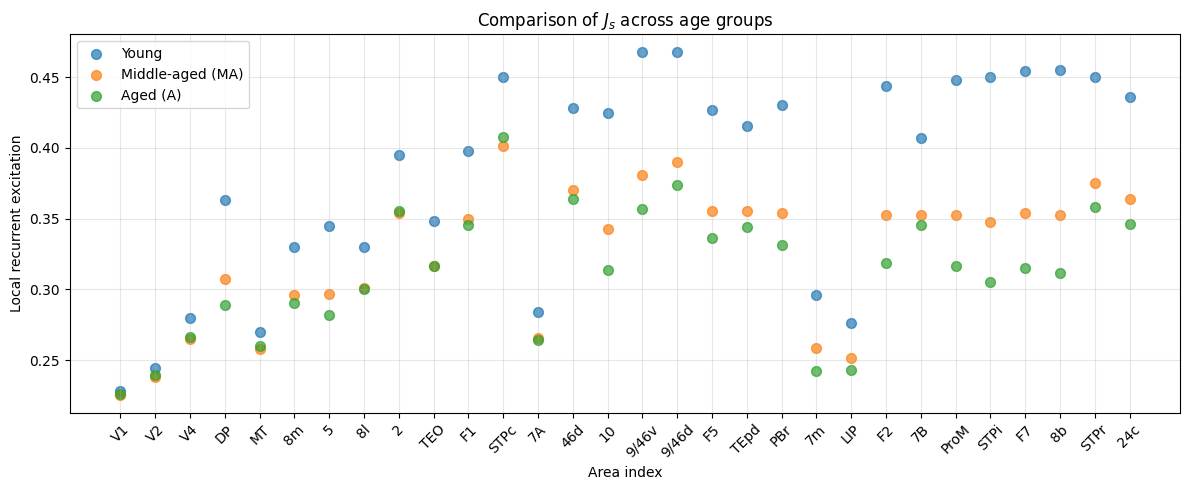

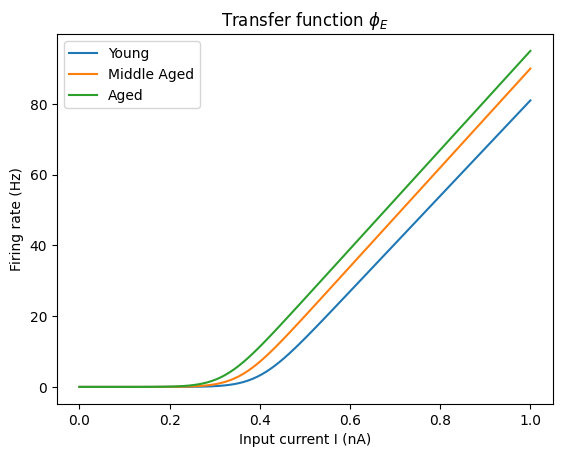

In [4]:
mech = ('FI', 'spine')
A = BuildModel(age='Y', aging_mechanism=mech, J_max=0.468,G=0.21)
C = BuildModel(age="MA", aging_mechanism=mech, J_max=0.468,G=0.21)
D = BuildModel(age="A", aging_mechanism=mech, J_max=0.468,G=0.21)

# Fig 1
plt.figure(figsize=(12, 5))

plt.scatter(range(30), A.g_E_self, label='Young', alpha=0.7, s=50)
plt.scatter(range(30), C.g_E_self, label='Middle-aged (MA)', alpha=0.7, s=50)
plt.scatter(range(30), D.g_E_self, label='Aged (A)', alpha=0.7, s=50)

print('g_E_self_min = 0.21  # nA ',min(A.g_E_self), min(C.g_E_self), min(D.g_E_self))
plt.xlabel('Area index')
plt.ylabel(fr'Local recurrent excitation')
plt.title(fr'Comparison of $J_s$ across age groups')

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(C.num_areas), C.area_list, rotation=45)
plt.tight_layout()
plt.show()

def phi_E_2(I, a_E, b_E, d_E):
    return (a_E * I - b_E) / (1 - np.exp(-d_E * (a_E * I - b_E)))

xc = np.linspace(0,1,100)
for a,b,age in zip([135,140,140], [54,50,45],['Young', 'Middle Aged', 'Aged']):
    plt.plot(xc,phi_E_2(xc, a, b, 0.308 ), label=fr"{age}")
plt.title(fr'Transfer function $\phi_E$')
plt.legend()
plt.xlabel('Input current I (nA)')
plt.ylabel('Firing rate (Hz)')
plt.show()

## Aging and Inactivating

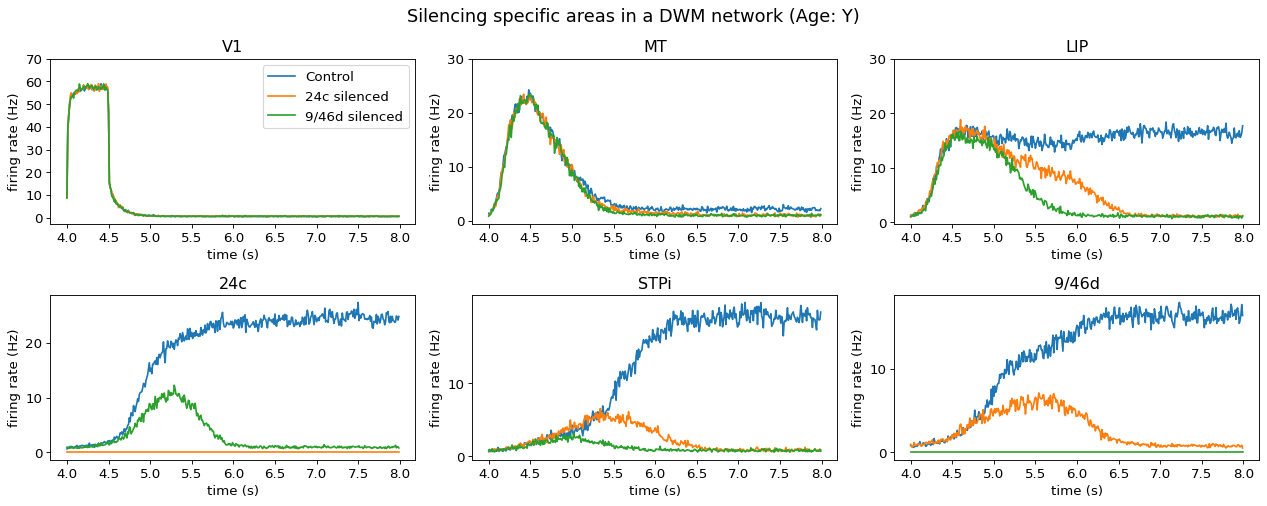

In [5]:

B = BuildModel(J_max=0.26,G=0.48, aging_mechanism=mech,age='Y') 
selection = ['V1', 'MT', 'LIP', '24c', 'STPi', '9/46d'] # which plots to show

fig = plt.figure(figsize=(16,3*len(selection)), dpi= 80, facecolor='w', edgecolor='k')

for area in [None, '24c', '9/46d']: # areas to silence
    B.runsim(lesion = [ 'perm', area]) # silence the area here
    R_E1 = B.R[:,:B.num_areas,0]

    times = np.arange(4, 8, B.dt_rate)
    plt.rcParams.update({'font.size': 12})

    for i in range(1,len(selection)+1):
        ax = plt.subplot(len(selection),3,i)
        ax.set_title(selection[i-1])
        # Plot the rates for the E1 soma
        plt.subplots_adjust(hspace = 1)
        subset = np.where(np.isin(np.array(B.area_list), selection[i-1]))[0]
        plt.plot(times, R_E1[int(4/B.dt_rate):int(8/B.dt_rate),subset])        
        
        # Place text above the black line
        axes = plt.gca()
        if i == 1:
            plt.legend(['Control', '24c silenced', '9/46d silenced'])
        plt.xlabel('time (s)')
        plt.ylabel('firing rate (Hz)')
        plt.yticks(np.arange(0,np.max(R_E1[int(4/B.dt_rate):int(8/B.dt_rate),subset])+15, 10) )
fig.suptitle(f'Silencing specific areas in a DWM network (Age: Y)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [ ]:
def Inact_task(J_max,G, mech=('spine','FI'), lesions = [None, '24c', '9/46d']):
    trials = 100
    ages = ['Y', 'MA', 'A']

    rows_E1 = []
    act_row = []
    # Collect data in long format
    for age in ages:
        B = BuildModel(J_max=J_max, G=G, aging_mechanism=mech, age=age)
        
        for lesion in lesions:
            B.runsim(stim=[4, 4.5, 3, 'V1'], lesion=[True, lesion], trials=trials, trial_length = 20)

            R_E1 = B.R[:, :B.num_areas]
            R_E2 = B.R[:, B.num_areas: 2*B.num_areas]
            
            # Activity check (post-stim)
            mean_E1_post = np.mean(R_E1[-500:], axis=0)   # (areas, trials)
            mean_E2_post = np.mean(R_E2[-500:], axis=0)
            fr_diff_post = mean_E1_post - mean_E2_post
            # We check for activity in both E1 and E2 at the end of the trial
            act_mask = np.count_nonzero(np.abs(fr_diff_post) > 5, axis=0) > 0  # (trials,)

            # Hallucination check (pre-stim and pre-distractor)
            mean_E1_pre = np.mean(R_E1[300:400], axis=0)
            mean_E2_pre = np.mean(R_E2[300:400], axis=0)
            fr_diff_pre = mean_E1_pre - mean_E2_pre

            mean_E1_post = np.mean(R_E1[-500:], axis=0)         # Compute the mean fr after the stimulus
            mean_E2_post = np.mean(R_E2[-500:], axis=0)         # (n_areas,trials)
            fr_diff_post = mean_E1_post - mean_E2_post          # (n_areas,trials)

            hall_areas = np.count_nonzero( (np.abs(fr_diff_pre) > 5) | (fr_diff_post < -5), axis=0 ) # Compute whether there is activity per area; (trials,)

            no_hall_mask = hall_areas == 0
            
            R_valid = B.R[:,:, act_mask & no_hall_mask]
            
            print(f'Numb of valid trials for {age} network with {lesion} lesion: {R_valid.shape[-1]}')
            if R_valid.shape[-1]/trials <= 0.4:
                # skip only this age, keep processing the rest
                continue

            R_E1 = R_valid[:, :B.num_areas, :]                 # (timesteps, areas, trials)
            R_E2 = R_valid[:, B.num_areas:2*B.num_areas, :]
            
            mean_fr_E1 = np.mean(R_E1, axis=0)
            mean_fr_E2 = np.mean(R_E2, axis=0)
            counts = mean_fr_E1 - mean_fr_E2 > 5  # (areas, trials)
            active_areas = np.count_nonzero(counts, axis=0)

            for i,val in enumerate(active_areas):
                rows_E1.append({
                    'Age': age,
                    'Lesion': 'None' if lesion is None else lesion,
                    'ActiveAreas': val*100/30
                })
                for j,count in enumerate(counts[:,i]):
                    act_row.append({
                        'Age': age,
                        'Area': B.area_list[j],
                        'Lesion': 'None' if lesion is None else lesion,
                        'ActiveAreas': int(count)
                    })

    df = pd.DataFrame(rows_E1)    
    df_act = pd.DataFrame(act_row)

    if df.empty or df_act.empty:
        print('No valid trials for this pair and aging mechanism')
        return None

    return df, df_act

    # trials = 50 takes 2m29

df, df_act = Inac_task(J_max=0.42,G=0.48, mech=('spine','FI'))


Numb of valid trials for Y network with None lesion: 100
Numb of valid trials for Y network with 24c lesion: 100
Numb of valid trials for Y network with 9/46d lesion: 100
Numb of valid trials for MA network with None lesion: 100
Numb of valid trials for MA network with 24c lesion: 100
Numb of valid trials for MA network with 9/46d lesion: 100
Numb of valid trials for A network with None lesion: 71
Numb of valid trials for A network with 24c lesion: 100
Numb of valid trials for A network with 9/46d lesion: 99


<Figure size 700x400 with 0 Axes>

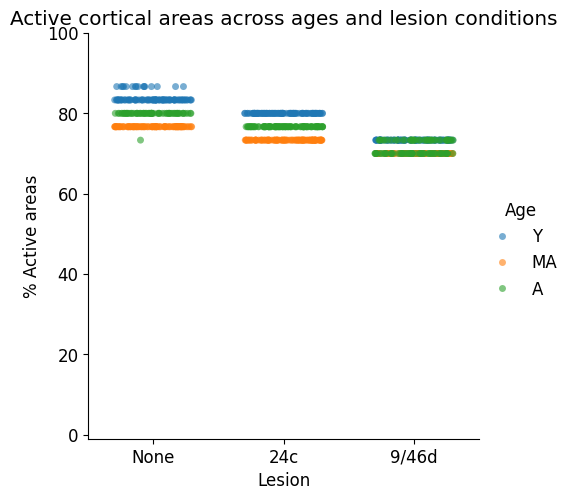

In [7]:
# Plot
plt.figure(figsize=(7, 4))

g = sns.catplot(
    data=df,
    hue='Age',
    y='ActiveAreas',
    x='Lesion',
    palette='tab10',
    alpha=0.6,
    jitter=0.3, 
)
plt.xlabel('Lesion')
plt.ylabel('% Active areas')
plt.title('Active cortical areas across ages and lesion conditions')
plt.ylim(top=100, bottom=-1)
plt.show()



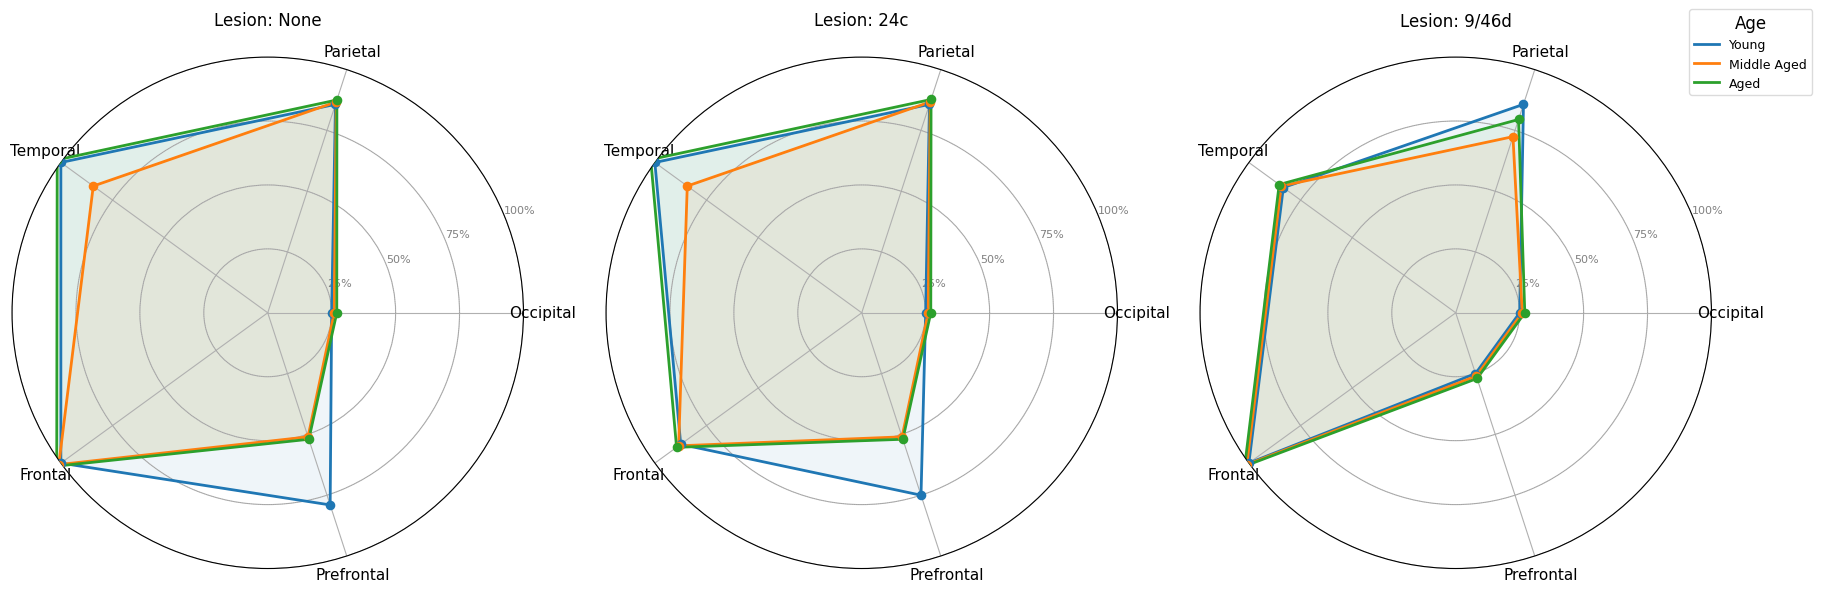

In [8]:
# Define desired ordering
age_jitter = {'Y': 0, 'MA': 0.01, 'A': 0.02}
age_order = ['Y', 'MA', 'A']
lesion_order = ['None', '24c', '9/46d']
area_to_lobe = {
    'V1': 'Occipital', 'V2': 'Occipital', 'V4': 'Occipital', 'MT': 'Occipital',
    'DP': 'Parietal', '5': 'Parietal', '2': 'Parietal', '7A': 'Parietal',
    '7m': 'Parietal', 'LIP': 'Parietal', '7B': 'Parietal',
    'TEO': 'Temporal', 'STPc': 'Temporal', 'TEpd': 'Temporal', 'PBr': 'Temporal',
    'STPi': 'Temporal', 'STPr': 'Temporal',
    '8m': 'Prefrontal', '8l': 'Prefrontal', '9/46v': 'Prefrontal', '9/46d': 'Prefrontal',
    '8B': 'Prefrontal',
    'F1': 'Frontal', '46d': 'Frontal', '10': 'Frontal', 'F5': 'Frontal',
    'F2': 'Frontal', 'ProM': 'Frontal', 'F7': 'Frontal', '24c': 'Frontal',
}
full_ages = {'Y': 'Young', 'MA': 'Middle Aged', 'A': 'Aged'}
age_colors = {'Y': 'tab:blue', 'MA': 'tab:orange', 'A': 'tab:green'}

# Convert to ordered categorical variables
df_act['Age'] = pd.Categorical(df_act['Age'], categories=age_order, ordered=True)
df_act['Lesion'] = pd.Categorical(df_act['Lesion'], categories=lesion_order, ordered=True)
# Compute activation frequency
freq_df = (df_act.groupby(['Age', 'Lesion', 'Area'],observed=False)['ActiveAreas'].mean().reset_index())

# Map areas to lobes and aggregate
freq_df['Lobe'] = freq_df['Area'].map(area_to_lobe)
lobe_freq = (freq_df.groupby(['Age', 'Lesion', 'Lobe'],observed=False)['ActiveAreas'].mean().reset_index())

region_names = ['Occipital', 'Parietal', 'Temporal', 'Frontal', 'Prefrontal']
N = len(region_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_plot = angles + [angles[0]]

fig, axes = plt.subplots(1, len(lesion_order), figsize=(6*len(lesion_order), 6),
                          subplot_kw=dict(polar=True))

for li, lesion in enumerate(lesion_order):
    ax = axes[li] if len(lesion_order) > 1 else axes
    for r in [0.25, 0.5, 0.75, 1.0]:
        ax.plot(np.linspace(0, 2*np.pi, 200), [r]*200, color='gray', linewidth=0.5, linestyle=':', alpha=0.4)

    for age in age_order:
        sub = lobe_freq[(lobe_freq['Age'] == age) & (lobe_freq['Lesion'] == lesion)]
        # ensure region order matches region_names, fill missing lobes with 0
        fracs = [float(sub.loc[sub['Lobe'] == region, 'ActiveAreas'].values[0] + age_jitter[age])
                  if region in sub['Lobe'].values else 0.0
                  for region in region_names]

        color = age_colors[age]
        ax.plot(angles_plot, fracs + [fracs[0]], color=color, linewidth=2)
        ax.fill(angles_plot, fracs + [fracs[0]], color=color, alpha=0.07)
        ax.scatter(angles, fracs, color=color, s=35, zorder=5)

    ax.set_thetagrids(np.degrees(angles), region_names, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
    ax.set_rlabel_position(22.5)
    ax.set_title(f'Lesion: {lesion}', va='bottom', fontsize=12, pad=20)

age_handles = [Line2D([0], [0], color=age_colors[a], linewidth=2, label=full_ages[a])
               for a in age_order]
fig.legend(handles=age_handles, loc='upper right', bbox_to_anchor=(1.02, 1.0),
           fontsize=9, title='Age', framealpha=0.7)

plt.tight_layout()
plt.show()

## Aging and Temporary Inhibition

<Figure size 700x400 with 0 Axes>

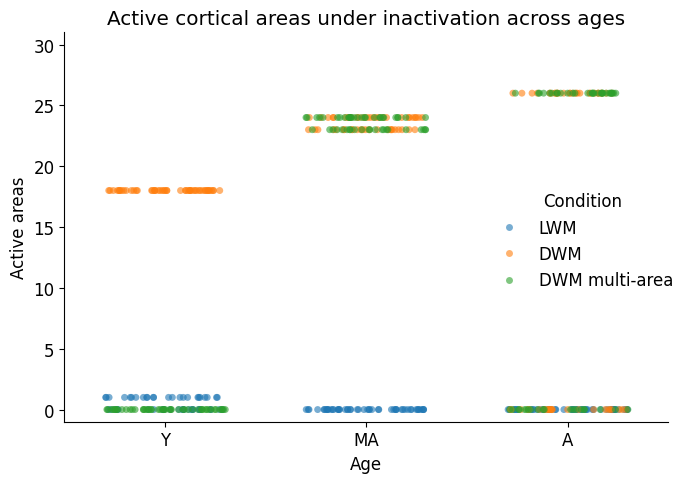

In [ ]:
def Inhib_task(J_max,G,mech= ('spine','FI')):
    trials = 100
    ages = ['Y', 'MA', 'A']
    rows = []
    for age in ages:
        for J_max, G, sil_areas, dur, Tit in zip([0.468, 0.26, 0.26],
                                                        [0.21, 0.48, 0.48],
                                                        [['9/46d', '9/46v'],
                                                        ['9/46d', '9/46v'],
                                                        ['9/46d', '9/46v', 'F7', '8B']],
                                                        [9.5, 9.5, 10],
                                                        [   'LWM',
                                                            'DWM',
                                                            'DWM multi-area']):
            B = BuildModel(J_max=J_max, G=G, aging_mechanism=mech, age=age)
            B.runsim(stim=[4, 5, 0.4, 'V1'], trial_length=20, inhi=[9, dur, 0.15, sil_areas], trials=trials)

            R_E1 = B.R[-500:, :B.num_areas]
            R_E2 = B.R[-500:, B.num_areas: 2*B.num_areas]
            mean_fr_E1 = np.mean(R_E1, axis=0)
            mean_fr_E2 = np.mean(R_E2, axis=0)
            active_areas = np.count_nonzero(mean_fr_E1 - mean_fr_E2 > 5, axis=0)

            for val in active_areas:
                rows.append({
                    'Age': age,
                    'Condition': Tit,
                    'ActiveAreas': val
                })

df = pd.DataFrame(rows)

plt.figure(figsize=(7, 4))

sns.catplot(
    data=df,
    x='Age',
    y='ActiveAreas',
    hue='Condition',
    palette='tab10',
    alpha=0.6,
    jitter=0.3,
)

plt.xlabel('Age')
plt.ylabel('Active areas')
plt.title('Active cortical areas under inactivation across ages')
plt.tight_layout()
plt.ylim(top=31, bottom=-1)
plt.show()

In [18]:
def _process_trials(B):
    """Apply activity + hallucination masks, return valid-trial data."""
    R_E1 = B.R[:, :B.num_areas]
    R_E2 = B.R[:, B.num_areas:2*B.num_areas]

    mean_E1_post = np.mean(R_E1[-500:], axis=0)
    mean_E2_post = np.mean(R_E2[-500:], axis=0)
    fr_diff_post = mean_E1_post - mean_E2_post
    act_mask = np.count_nonzero(np.abs(fr_diff_post) > 5, axis=0) > 0

    mean_E1_pre = np.mean(R_E1[300:400], axis=0)
    mean_E2_pre = np.mean(R_E2[300:400], axis=0)
    fr_diff_pre = mean_E1_pre - mean_E2_pre
    hall_areas = np.count_nonzero( (np.abs(fr_diff_pre) > 5) | (fr_diff_post < -5), axis=0)
    no_hall_mask = hall_areas == 0

    valid_mask = act_mask & no_hall_mask
    return B.R[:, :, valid_mask], valid_mask


def _collect_rows(B, R_valid, age, condition_label, trials, rows_summary, rows_area):
    n_valid = R_valid.shape[-1]
    print(f'Valid trials for {age}, condition "{condition_label}": {n_valid}')
    if n_valid / trials <= 0.4:
        return  # skip this age/condition, keep processing the rest

    R_E1 = R_valid[:, :B.num_areas, :]
    R_E2 = R_valid[:, B.num_areas:2*B.num_areas, :]
    mean_fr_E1 = np.mean(R_E1, axis=0)
    mean_fr_E2 = np.mean(R_E2, axis=0)
    counts = mean_fr_E1 - mean_fr_E2 > 5           # (areas, trials)
    active_areas = np.count_nonzero(counts, axis=0)

    for i, val in enumerate(active_areas):
        rows_summary.append({
            'Age': age, 'Condition': condition_label, 'ActiveAreas': val * 100 / 30
        })
        for j, count in enumerate(counts[:, i]):
            rows_area.append({
                'Age': age, 'Area': B.area_list[j],
                'Condition': condition_label, 'ActiveAreas': int(count)
            })


def Silencing_task(J_max, G, mech=('spine', 'FI'), mode='lesion',
                    lesions=(None, '24c', '9/46d'),
                    inhib_conditions=None,
                    trials=100, trial_length=20):
    """
    mode='lesion': permanently silence each area in `lesions` (uses J_max, G, mech).
    mode='inhib' : temporarily inhibit areas per `inhib_conditions`, a list of
                   (J_max, G, sil_areas, dur, label) tuples, applied to every age.
    """
    ages = ['Y', 'MA', 'A']
    rows_summary, rows_area = [], []

    for age in ages:
        B = BuildModel(J_max=J_max, G=G, aging_mechanism=mech, age=age)

        if mode == 'lesion':
            for lesion in lesions:
                B.runsim(stim=[4, 4.5, 3, 'V1'], lesion=[True, lesion],
                          trials=trials, trial_length=trial_length)
                R_valid, _ = _process_trials(B)
                label = 'None' if lesion is None else lesion
                _collect_rows(B, R_valid, age, label, trials, rows_summary, rows_area)

        elif mode == 'inhib':
            if inhib_conditions is None:
                raise ValueError("Provide inhib_conditions=[(J_max, G, sil_areas, dur, label), ...]")
            for sil_areas, dur in inhib_conditions:
                B.runsim(stim=[4, 5, 3, 'V1'], inhi=[9, dur, 0.15, sil_areas],
                          trials=trials, trial_length=trial_length)
                R_valid, _ = _process_trials(B)
                label = sil_areas
                _collect_rows(B, R_valid, age, label, trials, rows_summary, rows_area)
        else:
            raise ValueError("mode must be 'lesion' or 'inhib'")

    df = pd.DataFrame(rows_summary)
    df_act = pd.DataFrame(rows_area)

    if df.empty or df_act.empty:
        print('No valid trials for this pair and aging mechanism')
        return None
    return df, df_act


df, df_act = Silencing_task(J_max=0.42,G=0.48, mech=('spine','FI'))


True
True
Valid trials for Y, condition "None": 100
True
True
Valid trials for Y, condition "24c": 100
True
True
Valid trials for Y, condition "9/46d": 100
True
True
Valid trials for MA, condition "None": 100
True
True
Valid trials for MA, condition "24c": 100
True
True
Valid trials for MA, condition "9/46d": 100
True
True


KeyboardInterrupt: 

## Aging and Distractions

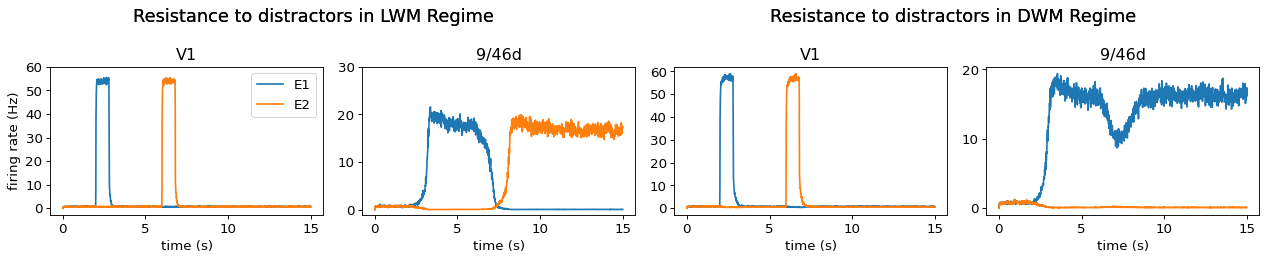

In [10]:

h=0

mech = ('spine','FI')
fig = plt.figure(figsize=(16,5), dpi= 80, facecolor='w', edgecolor='k')
for J_max, G in zip([0.468, 0.26 ],  [0.21, 0.48]):
    B = BuildModel(J_max=J_max,G=G)
    selection = ['V1', '9/46d'] # which plots to show
    B.runsim(stim=[2, 2.8, 0.3, 'V1'], trial_length = 15, distract=[ 6, 6.8, 0.3] )
    
    subset = np.where(np.isin(np.array(B.area_list), selection))[0]

    R_E1 = B.R[:,:B.num_areas,0]
    R_E2 = B.R[:,B.num_areas:2*B.num_areas,0]        

    times = np.arange(0, B.trial_length, B.dt_rate)
    plt.rcParams.update({'font.size': 12})

    for i in range(h+1,len(selection)+1+h):
        ax = plt.subplot(len(selection),4,i)
        ax.set_title(selection[(i-1)%2])
        # Plot the rates for the E1 soma
        plt.subplots_adjust(hspace = 1)
        subset = np.where(np.isin(np.array(B.area_list), selection[(i-1)%2]))[0]
        plt.plot(times, R_E1[:,subset], label="E1", color='tab:blue')        
        plt.plot(times, R_E2[:,subset], label="E2", color='tab:orange')  

        # axes = plt.gca()
        if i==1:
            plt.ylabel('firing rate (Hz)')
            plt.legend()

        plt.xlabel('time (s)')
        plt.yticks(np.arange(0,np.max(R_E1[:,subset])+10, 10))
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    fig.text(0.25, 1.02, "Resistance to distractors in LWM Regime", ha="center", fontsize=16)
    fig.text(0.75, 1.02, "Resistance to distractors in DWM Regime", ha="center", fontsize=16)
    h=2
plt.savefig(f'Fig/Distractor/distractors_examples.svg', dpi=150, bbox_inches='tight')
plt.show()


# for J_max, G in zip([0.468, 0.26 ],  [0.21, 0.48]):
#     B = BuildModel(J_max=J_max,G=G)
#     B.runsim(stim=[2, 2.8, 0.3, 'V1'], trial_length = 15, distract=[ 6, 6.8, 0.3] )
#     B.plot_raster(pops=2)


In [11]:

def Dist_task(J_max,G, mech=('spine','FI')):
    ages   = ['Y', 'MA', 'A']
    trials = 100
    full_ages = {'Y':'Young', 'MA':'Middle Aged', 'A':'Aged'}

    rows   = []
    # for age in ages:
    for age in ages:
        # for J_max, G, Tit in zip([0.468, 0.26], [0.21, 0.48], ["LWM", "DWM"]):

            B = BuildModel(J_max=J_max, G=G, aging_mechanism=mech, age=age)
            B.runsim(stim=[4, 4.5, 0.3, 'V1'], trial_length=20, distract=[8, 8.5, 0.3], trials=trials)

            R_E1 = B.R[:, :B.num_areas, :]                 # (timesteps, areas, trials)
            R_E2 = B.R[:, B.num_areas:2*B.num_areas, :]
            
            # Activity check (post-stim)
            mean_E1_post = np.mean(R_E1[-500:], axis=0)   # (areas, trials)
            mean_E2_post = np.mean(R_E2[-500:], axis=0)
            fr_diff_post = mean_E1_post - mean_E2_post
            # We check for activity in both E1 and E2 at the end of the trial
            act_mask = np.count_nonzero(np.abs(fr_diff_post) > 5, axis=0) > 0  # (trials,)

            # Hallucination check (pre-stim and pre-distractor)
            mean_E1_pre1 = np.mean(R_E1[300:400], axis=0)
            mean_E2_pre1 = np.mean(R_E2[300:400], axis=0)
            fr_diff_pre1 = mean_E1_pre1 - mean_E2_pre1

            mean_E1_pre2 = np.mean(R_E1[700:800], axis=0)
            mean_E2_pre2 = np.mean(R_E2[700:800], axis=0)
            fr_diff_pre2 = mean_E1_pre2 - mean_E2_pre2

            # We check for no acitivy in E1 and E2 before the stimulus and no activity in E2 before distractor
            hall_areas = np.count_nonzero( (np.abs(fr_diff_pre1) > 5) | (fr_diff_pre2 < -5 ) , axis=0 )
            no_hall_mask = hall_areas == 0
            
            R_valid = B.R[:,:, act_mask & no_hall_mask]
            
            print(f'Numb of valid trials: {R_valid.shape[-1]}')
            if R_valid.shape[-1]/trials <= 0.4:
                # skip only this age, keep processing the rest
                continue

            R_E1 = R_valid[:, :B.num_areas, :]                 # (timesteps, areas, trials)
            R_E2 = R_valid[:, B.num_areas:2*B.num_areas, :]

            for pop_name, R_pop in [('E1', R_E1), ('E2', R_E2)]:

                # Average over the time window, (areas, trials)
                mean_pre  = np.mean(R_pop[300:400,:,:],  axis=0)
                mean_post = np.mean(R_pop[-500:,:,:], axis=0)

                # Compute wether there is a change in activity per area per trial
                delta = mean_pre - mean_post   # (areas , trials)
                delta_trial = np.mean(delta, axis=0) # (trials,)
                
                for t in range(R_valid.shape[-1]):
                    rows.append({
                        'Age':        full_ages[age],
                        'Population': pop_name,
                        'Trial':      t,
                        'Delta':      delta_trial[t],
                    })

    df = pd.DataFrame(rows)
    if df.empty:
            print('No valid trials for this pair and aging mechanism')
            return None
    plt.figure()

    ax = sns.lineplot(
        data=df,
        x="Age", y="Delta",
        hue="Population",
        errorbar="sd", markers=True
    )

    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(r'$\Delta$' + " activity across age groups")
    plt.tight_layout()
    plt.savefig(f'Fig/Distractor/distractor_delta_{mech}.svg', dpi=150, bbox_inches='tight')
    plt.show()


# j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
# Gs      = [round(j * 0.02 + 0.2,  2) for j in range(16)]

# for G in Gs[10:]:
#     for J in j_maxes[:27]:
#         Dist_task(J_max = J, G=G, mech=('spine','FI'))


In [12]:
# import numpy as np
# import pandas as pd
# import matplotlib
# matplotlib.use('Agg')          # no GUI backend needed in worker/plot loop
# import matplotlib.pyplot as plt
# import seaborn as sns
# from joblib import Parallel, delayed
# import itertools
# import os

# FULL_AGES = {'Y': 'Young', 'MA': 'Middle Aged', 'A': 'Aged'}


# def compute_pair(J_max, G, mech=('spine', 'FI'), age='A', trials=100, threshold_frac=0.4):
#     """
#     Run one (J_max, G) distractor simulation, apply the activity /
#     hallucination filtering, and report whether this pair yields
#     enough valid trials. Returns a summary dict; per-trial delta rows
#     are only included when the pair is valid, so plotting can be done
#     later without re-simulating.
#     """
#     B = BuildModel(J_max=J_max, G=G, aging_mechanism=mech, age=age)
#     B.runsim(stim=[4, 4.5, 0.3, 'V1'], trial_length=20,
#               distract=[8, 8.5, 0.3], trials=trials)

#     R_E1 = B.R[:, :B.num_areas, :]
#     R_E2 = B.R[:, B.num_areas:2 * B.num_areas, :]

#     mean_E1_post = np.mean(R_E1[-500:], axis=0)
#     mean_E2_post = np.mean(R_E2[-500:], axis=0)
#     fr_diff_post = mean_E1_post - mean_E2_post
#     act_mask = np.count_nonzero(np.abs(fr_diff_post) > 5, axis=0) > 0

#     mean_E1_pre1 = np.mean(R_E1[300:400], axis=0)
#     mean_E2_pre1 = np.mean(R_E2[300:400], axis=0)
#     fr_diff_pre1 = mean_E1_pre1 - mean_E2_pre1
#     mean_E1_pre2 = np.mean(R_E1[700:800], axis=0)
#     mean_E2_pre2 = np.mean(R_E2[700:800], axis=0)
#     fr_diff_pre2 = mean_E1_pre2 - mean_E2_pre2
#     hall_areas = np.count_nonzero((np.abs(fr_diff_pre1) > 5) | (fr_diff_pre2 < 5), axis=0)
#     no_hall_mask = hall_areas == 0

#     valid = act_mask & no_hall_mask
#     n_valid = int(np.count_nonzero(valid))
#     frac_valid = n_valid / trials
#     is_valid_pair = frac_valid > threshold_frac

#     result = {
#         'J_max': J_max, 'G': G, 'mech': mech, 'age': age,
#         'n_valid': n_valid, 'frac_valid': frac_valid,
#         'is_valid_pair': is_valid_pair,
#     }
#     if not is_valid_pair:
#         return result

# if __name__ == '__main__':
#     mech = ('spine', 'FI')
#     j_maxes = [round(i * 0.01 + 0.21, 2) for i in range(31)]
#     Gs      = [round(j * 0.02 + 0.2, 2) for j in range(16)]

#     pairs = list(itertools.product(Gs[10:], j_maxes[:27]))  # (G, J_max)
#     print(f"Total tasks: {len(pairs)}")

#     os.makedirs('Fig/Distractor', exist_ok=True)

#     # n_jobs: tune to your core/RAM budget. Each worker holds a full B.R
#     # array (timesteps x 2*num_areas x trials), so don't just blast -1
#     # if that's large — start conservative (e.g. 6-8) and watch memory.
#     results = Parallel(n_jobs=10, backend='loky', verbose=10)(
#         delayed(compute_pair)(J_max, G, mech) for G, J_max in pairs
#     )

#     summary_df = pd.DataFrame(
#         [{k: v for k, v in r.items() if k != 'rows'} for r in results]
#     )
#     summary_df.to_csv('Fig/Distractor/valid_pairs_summary.csv', index=False)

#     valid_pairs = summary_df[summary_df['is_valid_pair']]
#     print(f"{len(valid_pairs)} / {len(summary_df)} pairs valid "
#           f"(frac_valid > 0.4)")
#     print(valid_pairs[['J_max', 'G', 'frac_valid']].to_string(index=False))

#     # Plotting only for valid pairs, in the main process
#     for r in results:
#         if not r['is_valid_pair']:
#             continue
#         df = pd.DataFrame(r['rows'])
#         plt.figure()
#         ax = sns.lineplot(data=df, x="Age", y="Delta", hue="Population",
#                            errorbar="sd", markers=True)
#         ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
#         ax.set_title(r'$\Delta$' + f" activity (J_max={r['J_max']}, G={r['G']})")
#         plt.tight_layout()
#         fname = (f"Fig/Distractor/distractor_delta_{r['mech']}"
#                   f"_J{r['J_max']}_G{r['G']}.svg")
#         plt.savefig(fname, dpi=150, bbox_inches='tight')
#         plt.close()